# PINN example notebook: Logistic Regression

This is an example notebook to learn the basics of Pysics Informed Neural Networks (PINNs) with a very simple example:|
Logistic Regression

The differential equation for logistic regression can be solved analytically. \
Using a neural network to learn this solution to the problem aims to explain the concept and application of a PINN to differential equations in general.

# Import Libraries

In [1]:
import torch 
import torchopt

import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

from torch.func import grad, vmap

import torch.nn as nn

# Create a model class

In [2]:
# NNApproximator will be the neural network consisting of an input layer, 
# an output layer, hidden layers in betwee n and tanh as activation function
class NNApproximator(nn.Module):
    def __init__(
        self,
        num_inputs: int = 1,
        num_outputs: int = 1,
        num_hidden: int = 2,
        dim_hidden: int = 2,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            num_inputs (int, optional): The number of input dimensions
            num_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layeim_hidden rs in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()

        # creates linear input and output layers 
        
        # input layer has num_input inputs neurons and dim_hidden outputs
        self.layer_in = nn.Linear(num_inputs, dim_hidden)
        # output layer has dim_hidden inputs neurons and num_outputs outputs
        self.layer_out = nn.Linear(dim_hidden, num_outputs)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


# Intialisation of the model

In [3]:
# create the PINN model
model = NNApproximator()
# create a dictionary using the parameter names connected with its values
params = dict(model.named_parameters())

# Applying vmap and grad

In [4]:
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x):
    
    return model(x.unsqueeze(0)).squeeze(0)

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)

# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)

# Defining a loss function

In [5]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value

# defining a loss function consisting of two parts
# first part calculates the loss in resect to the differential equation
# second parts sets bounday conditions so that the solution converges
def loss_fn(params: torch.Tensor, x: torch.Tensor, model_v) -> torch.Tensor:

    # interior loss
    f_value = model_v(x)
    
    interior = diff_model_v(x)- R * f_value * (1 - f_value)

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    # calculates difference between the the functional value at the boundary and the aimed value
    boundary = model_v(x_boundary)- f_boundary

    # calculates the mean squared error using the nn.MSELoss function
    loss = nn.MSELoss()
    # adding both losses to a total loss
    # the loss function takes its two inputs and calculates the mse of those
    # therefore the second entry is a tensor with the same dimensions but with zeroes 
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    )

    return loss_value

# Training the model

In [6]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter =1000 # maximum number of iterations
learning_rate = 1e-3  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch


#list that keeps track of the loss evolution
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    output = model_v(x)
    
    #initializing  the optimizer with model parameters
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # update the parameters using the functional API
    loss = loss_fn(params, x, model_v)
    optimizer.zero_grad()  # Clear the gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update the model parameters
    

    print(f"Iteration {i} with loss {float(loss)}")
    
    #appends the loss from every iteration to the loss_evolution list
    loss_evolution.append(float(loss))

# plot solution on the given domain



Iteration 0 with loss 3.278230667114258
Iteration 1 with loss 3.2368102073669434
Iteration 2 with loss 3.2799692153930664
Iteration 3 with loss 3.2524876594543457
Iteration 4 with loss 3.232330083847046
Iteration 5 with loss 3.301914691925049
Iteration 6 with loss 3.097385883331299
Iteration 7 with loss 3.113429069519043
Iteration 8 with loss 3.102375030517578
Iteration 9 with loss 3.0688235759735107
Iteration 10 with loss 3.0755627155303955
Iteration 11 with loss 3.099339485168457
Iteration 12 with loss 2.9887747764587402
Iteration 13 with loss 3.0403575897216797
Iteration 14 with loss 3.0336575508117676
Iteration 15 with loss 2.991194248199463
Iteration 16 with loss 2.9814982414245605
Iteration 17 with loss 2.9519174098968506
Iteration 18 with loss 2.8980374336242676
Iteration 19 with loss 2.8877925872802734
Iteration 20 with loss 2.894991159439087
Iteration 21 with loss 2.8724684715270996
Iteration 22 with loss 2.895440101623535
Iteration 23 with loss 2.819901466369629
Iteration 24 

Iteration 210 with loss 0.842799723148346
Iteration 211 with loss 0.8334921598434448
Iteration 212 with loss 0.8376420140266418
Iteration 213 with loss 0.8163291811943054
Iteration 214 with loss 0.8144431710243225
Iteration 215 with loss 0.8246204853057861
Iteration 216 with loss 0.8198795318603516
Iteration 217 with loss 0.816157877445221
Iteration 218 with loss 0.8102874159812927
Iteration 219 with loss 0.8105190992355347
Iteration 220 with loss 0.7845490574836731
Iteration 221 with loss 0.8024989366531372
Iteration 222 with loss 0.7970972657203674
Iteration 223 with loss 0.7883502244949341
Iteration 224 with loss 0.7732756733894348
Iteration 225 with loss 0.774401068687439
Iteration 226 with loss 0.7583799958229065
Iteration 227 with loss 0.7692656517028809
Iteration 228 with loss 0.7630244493484497
Iteration 229 with loss 0.7554938793182373
Iteration 230 with loss 0.7387228012084961
Iteration 231 with loss 0.7481992244720459
Iteration 232 with loss 0.7507715225219727
Iteration 233 

Iteration 480 with loss 0.037148281931877136
Iteration 481 with loss 0.029615458101034164
Iteration 482 with loss 0.03369029983878136
Iteration 483 with loss 0.02815871685743332
Iteration 484 with loss 0.02272653579711914
Iteration 485 with loss 0.03056679666042328
Iteration 486 with loss 0.030144182965159416
Iteration 487 with loss 0.03332115337252617
Iteration 488 with loss 0.02690601535141468
Iteration 489 with loss 0.03024555929005146
Iteration 490 with loss 0.02934906631708145
Iteration 491 with loss 0.02630195952951908
Iteration 492 with loss 0.028542984277009964
Iteration 493 with loss 0.020693764090538025
Iteration 494 with loss 0.021745841950178146
Iteration 495 with loss 0.026348406448960304
Iteration 496 with loss 0.0236276276409626
Iteration 497 with loss 0.02936689555644989
Iteration 498 with loss 0.024905789643526077
Iteration 499 with loss 0.026510251685976982
Iteration 500 with loss 0.033851783722639084
Iteration 501 with loss 0.021845743060112
Iteration 502 with loss 0

Iteration 685 with loss 0.0105310482904315
Iteration 686 with loss 0.01240138616412878
Iteration 687 with loss 0.009102328680455685
Iteration 688 with loss 0.012111596763134003
Iteration 689 with loss 0.012332979589700699
Iteration 690 with loss 0.0074024745263159275
Iteration 691 with loss 0.010984036140143871
Iteration 692 with loss 0.008007971569895744
Iteration 693 with loss 0.011334018781781197
Iteration 694 with loss 0.011425552889704704
Iteration 695 with loss 0.010755447670817375
Iteration 696 with loss 0.01091341394931078
Iteration 697 with loss 0.009489843621850014
Iteration 698 with loss 0.009388558566570282
Iteration 699 with loss 0.009680633433163166
Iteration 700 with loss 0.010072671808302402
Iteration 701 with loss 0.010451276786625385
Iteration 702 with loss 0.012294760905206203
Iteration 703 with loss 0.009698242880403996
Iteration 704 with loss 0.00780973955988884
Iteration 705 with loss 0.009662007912993431
Iteration 706 with loss 0.0095774345099926
Iteration 707 wi

Iteration 953 with loss 0.0020617982372641563
Iteration 954 with loss 0.0018161735497415066
Iteration 955 with loss 0.0015839647967368364
Iteration 956 with loss 0.00187643151730299
Iteration 957 with loss 0.0015410727355629206
Iteration 958 with loss 0.0010499320924282074
Iteration 959 with loss 0.0013035155134275556
Iteration 960 with loss 0.002060588914901018
Iteration 961 with loss 0.0011664137709885836
Iteration 962 with loss 0.0013834269484505057
Iteration 963 with loss 0.0016506677493453026
Iteration 964 with loss 0.0012912536039948463
Iteration 965 with loss 0.0013781661400571465
Iteration 966 with loss 0.001490964787080884
Iteration 967 with loss 0.0012255767360329628
Iteration 968 with loss 0.0012447055196389556
Iteration 969 with loss 0.0012260782532393932
Iteration 970 with loss 0.0010803276672959328
Iteration 971 with loss 0.0015369351021945477
Iteration 972 with loss 0.001403944450430572
Iteration 973 with loss 0.0012723705731332302
Iteration 974 with loss 0.0016865080688

# Plotting the solution and the loss evolution

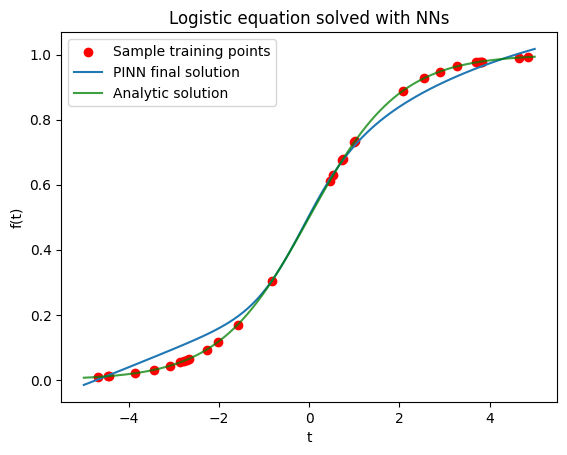

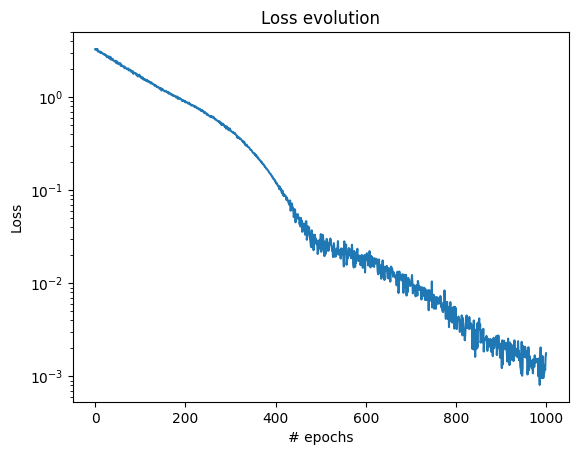

In [7]:
# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vector 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)

# evaluates the function values to the given x values
f_eval = model_v(x_eval).squeeze()

# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))

# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()

# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes for the first plot

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution, analytical solution, title and legend to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

#creates Figures and axes for the second plot
fig, ax = plt.subplots()
ax.semilogy(loss_evolution) #y-axis is logarithmic
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()